In [11]:
# Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Load the dataset
df = pd.read_csv('Titanic.csv')

In [13]:
# Display first few rows
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
0,1,3,Allison Hill,male,17,4,2,43d75413-a939-4bd1-a516-b0d47d3572cc,144.08,Q,1
1,2,1,Noah Rhodes,male,60,2,2,6334fa2a-8b4b-47e7-a451-5ae01754bf08,249.04,S,0
2,3,3,Angie Henderson,male,64,0,0,61a66444-e2af-4629-9efb-336e2f546033,50.31,Q,1
3,4,3,Daniel Wagner,male,35,4,0,0b6c03c8-721e-4419-afc3-e6495e911b91,235.20,C,1
4,5,1,Cristian Santos,female,70,0,3,436e3c49-770e-49db-b092-d40143675d58,160.17,C,1


In [14]:
# Basic structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1000 non-null   int64  
 1   Pclass       1000 non-null   int64  
 2   Name         1000 non-null   object 
 3   Sex          1000 non-null   object 
 4   Age          1000 non-null   int64  
 5   SibSp        1000 non-null   int64  
 6   Parch        1000 non-null   int64  
 7   Ticket       1000 non-null   object 
 8   Fare         1000 non-null   float64
 9   Embarked     1000 non-null   object 
 10  Survived     1000 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 86.1+ KB


In [15]:
# Summary statistics
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1.964000,38.458000,2.032000,2.005000,247.968650,0.492000
std,288.819436,0.820596,23.103723,1.424431,1.410306,139.301211,0.500186
min,1.000000,1.000000,1.000000,0.000000,0.000000,10.020000,0.000000
25%,250.750000,1.000000,19.000000,1.000000,1.000000,126.295000,0.000000
50%,500.500000,2.000000,36.500000,2.000000,2.000000,246.500000,0.000000
75%,750.250000,3.000000,59.000000,3.000000,3.000000,365.662500,1.000000
max,1000.000000,3.000000,79.000000,4.000000,4.000000,499.780000,1.000000


In [16]:
# Missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Survived       0
dtype: int64


In [17]:
# Value counts for key categorical columns
print("Survived Counts:\n", df['Survived'].value_counts())
print("Pclass Counts:\n", df['Pclass'].value_counts())
print("Sex Counts:\n", df['Sex'].value_counts())

Survived Counts:
 Survived
0    508
1    492
Name: count, dtype: int64
Pclass Counts:
 Pclass
1    355
2    326
3    319
Name: count, dtype: int64
Sex Counts:
 Sex
male      527
female    473
Name: count, dtype: int64


<Axes: title={'center': 'Fare'}, xlabel='Parch', ylabel='count'>

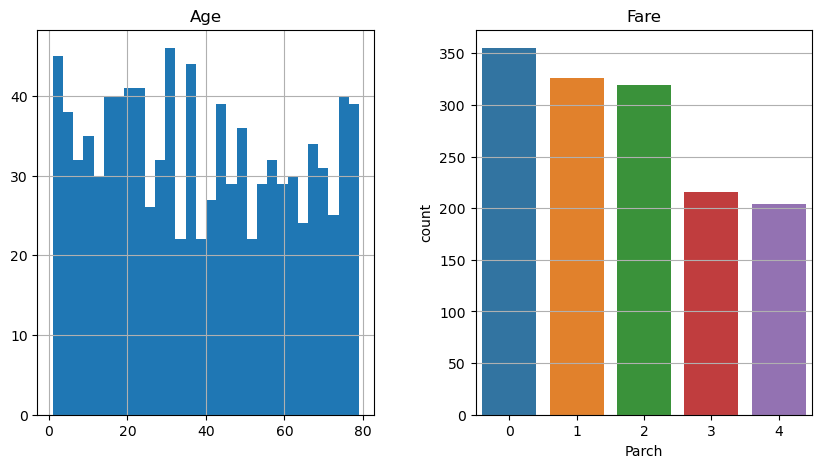

In [18]:
# Histograms for Numerical Features
df[['Age', 'Fare']].hist(bins=30, figsize=(10, 5))

sns.countplot(x='Pclass', data=df)
sns.countplot(x='SibSp', data=df)
sns.countplot(x='Parch', data=df)

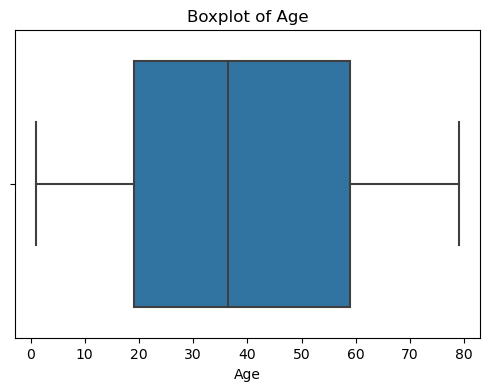

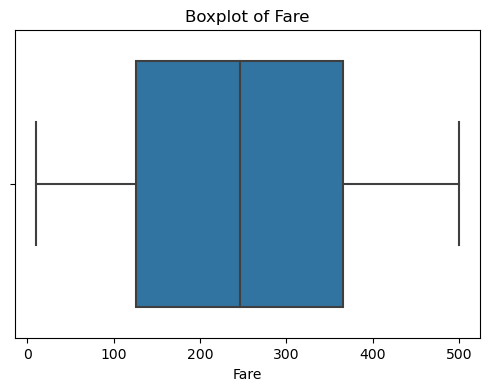

In [19]:
# Boxplots for Outlier Detection
for col in ['Age', 'Fare']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


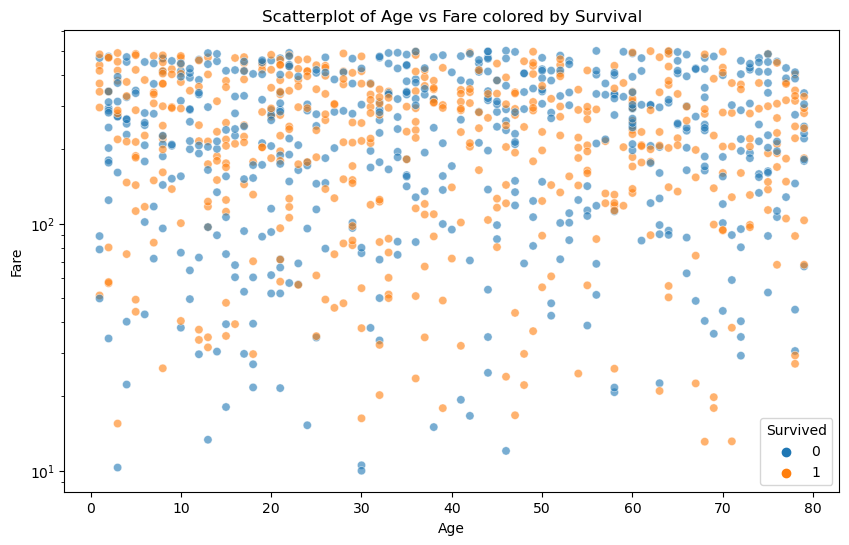

In [24]:
# Scatterplot: Age vs Fare colored by Survival

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, alpha=0.6)
plt.yscale('log')  # Optional: log scale for better fare distribution
plt.title('Scatterplot of Age vs Fare colored by Survival')
plt.show()

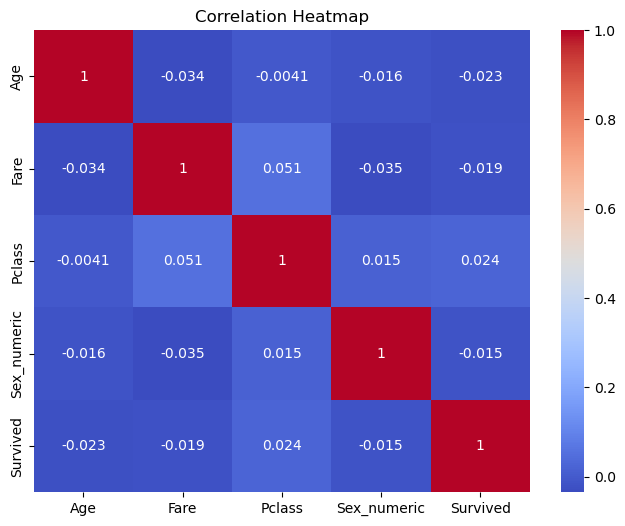

In [20]:
# Correlation Heatmap(Convert 'Sex' to numeric for correlation)
df['Sex_numeric'] = df['Sex'].map({'male': 0, 'female': 1})

plt.figure(figsize=(8, 6))
sns.heatmap(df[['Age', 'Fare', 'Pclass', 'Sex_numeric', 'Survived']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

C:\Users\nikit\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


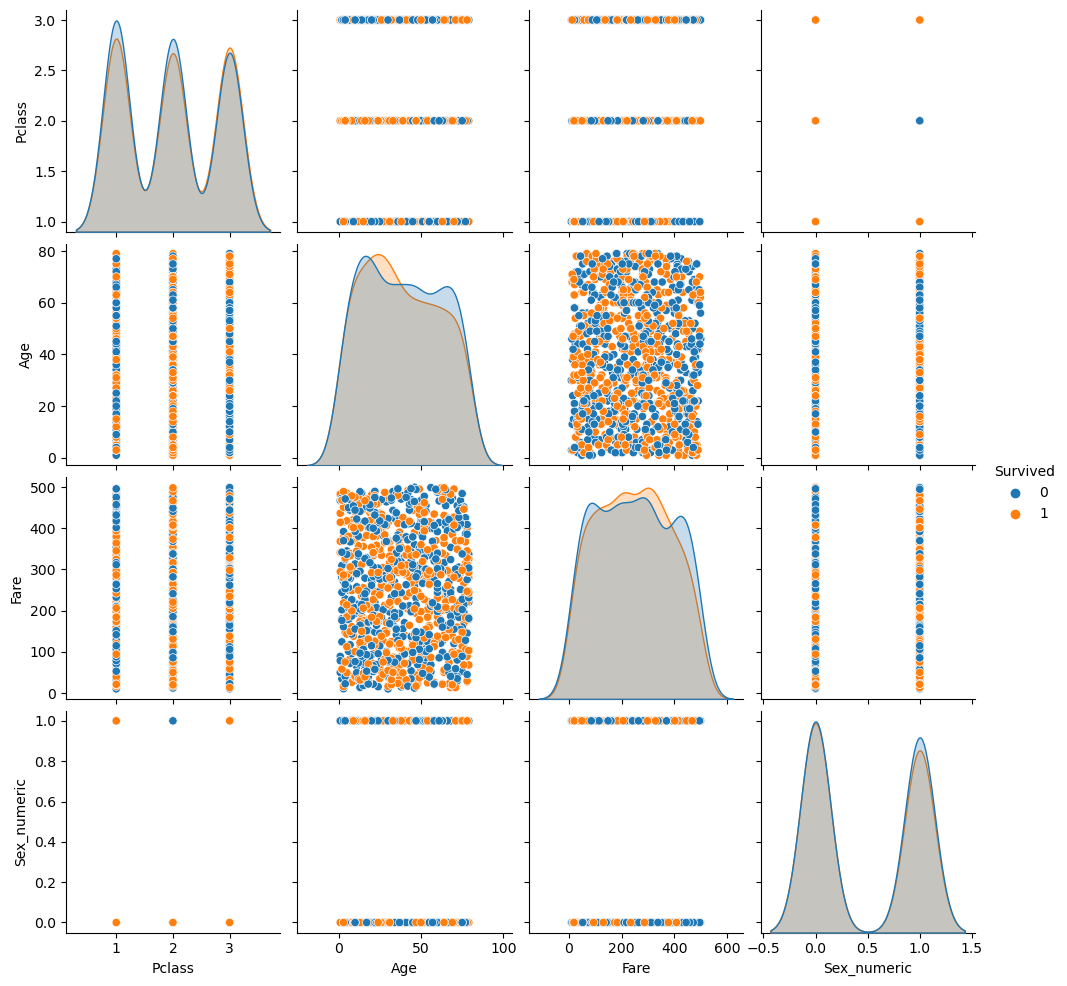

In [21]:
# Pairplot of Features
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare', 'Sex_numeric']], hue='Survived')
plt.show()

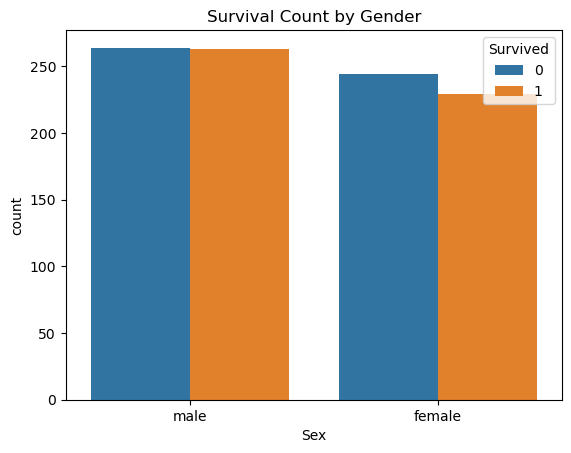

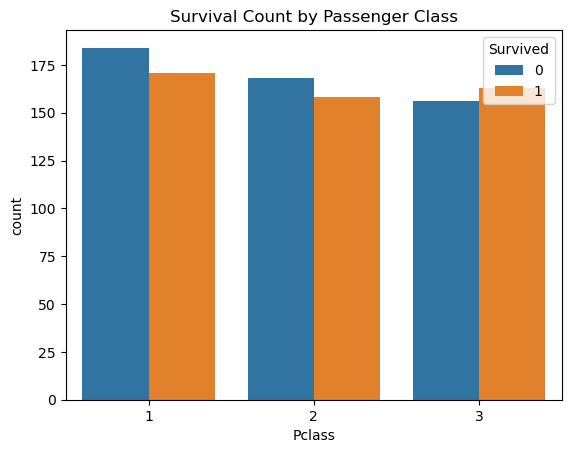

In [23]:
#Count Plots

# Survived by Gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival Count by Gender")
plt.show()

# Survived by Class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival Count by Passenger Class")
plt.show()